# BEAD Random Forest v2

### Changes from v1:
- **Added**: match funding features (how much non-BEAD money is in the project)
- **Added**: location type mix (% residential, % business, % CAI)
- **Added**: anticipated speed targets (avg download/upload per project)
- **Added**: baseline state broadband quality from NBM (avg advertised speeds)
- **Added**: aerial-to-total fiber ratio (proxy for terrain difficulty)
- **Dropped**: `avg_technology`, `avg_latency`, `priority_broadband_project`, `project_type` — near-zero variance, almost all projects are fiber/low-latency/priority/last-mile
- **Replaced**: 44 state dummies → 4 Census region dummies — reduces overfitting

In [28]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project="broadband-data")
print("Connected to BigQuery: broadband-data")

Connected to BigQuery: broadband-data


In [29]:
# --- Load project data ---
project_query = """
SELECT
    project_id,
    state,
    bead_support,
    estimated_miles_aerial_fiber,
    estimated_miles_buried_fiber,
    estimated_jobs,
    COALESCE(subgrantee_match, 0) AS subgrantee_match,
    COALESCE(federal_match, 0)    AS federal_match,
    COALESCE(state_match, 0)      AS state_match,
    COALESCE(other_match, 0)      AS other_match
FROM `broadband-data.fp_approved.deployment_projects`
"""
df_projects = client.query(project_query).to_dataframe()
print(f"Projects: {df_projects.shape}")
df_projects.head()

Projects: (5251, 10)


,project_id,state,bead_support,estimated_miles_aerial_fiber,estimated_miles_buried_fiber,estimated_jobs,subgrantee_match,federal_match,state_match,other_match
0,CM61-BEAD-WV-482636,WV,6830247.01,141.0,2.0,10,2276749.00,0.0,0.0,0.0
1,CM61-BEAD-WV-482635,WV,10204.02,0.0,0.0,10,3401.34,0.0,0.0,0.0
2,CM61-BEAD-WV-482647,WV,541412.31,10.0,1.0,10,180470.78,0.0,0.0,0.0
3,CM61-BEAD-WV-482312,WV,23269.21,0.0,0.0,10,7757.00,0.0,0.0,0.0
4,CM61-BEAD-WV-482335,WV,3006727.85,34.0,0.0,10,1002242.62,0.0,0.0,0.0


In [30]:
# --- Aggregate location data ---
location_query = """
SELECT
    project_id,
    COUNT(*) AS funded_locations,
    AVG(SAFE_CAST(download_speed_anticipated AS FLOAT64)) AS avg_download_speed,
    AVG(SAFE_CAST(upload_speed_anticipated AS FLOAT64))   AS avg_upload_speed,
    AVG(CASE WHEN classification = '0' THEN 1.0 ELSE 0.0 END) AS pct_residential,
    AVG(CASE WHEN classification = '1' THEN 1.0 ELSE 0.0 END) AS pct_business,
    AVG(CASE WHEN classification = '2' THEN 1.0 ELSE 0.0 END) AS pct_cai
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
"""
df_locations = client.query(location_query).to_dataframe()
print(f"Location aggregates: {df_locations.shape}")
df_locations.head()

Location aggregates: (5228, 7)


,project_id,funded_locations,avg_download_speed,avg_upload_speed,pct_residential,pct_business,pct_cai
0,CM61-BEAD-DE-Comcast2,2356,2000.0,2000.0,0.068761,0.931239,0.0
1,CM61-BEAD-HI-LEO-HAWAII,1062,100.0,20.0,0.968927,0.031073,0.0
2,CM61-BEAD-HI-LEO-KAUAI,77,100.0,20.0,0.987013,0.012987,0.0
3,CM61-BEAD-NJ-COM-BUR,894,2000.0,2000.0,0.768456,0.231544,0.0
4,CM61-BEAD-NJ-COM-HUD,253,2000.0,2000.0,0.667984,0.332016,0.0


In [31]:
# --- State-level features from NBM ---
# Added: baseline broadband quality (avg advertised speeds) as proxy for how underserved the state is
state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}

nbm_query = """
SELECT
    state,
    COUNT(DISTINCT frn)                        AS state_num_providers,
    AVG(max_advertised_download_speed)         AS state_avg_download_mbps,
    AVG(max_advertised_upload_speed)           AS state_avg_upload_mbps
FROM `broadband-data.fcc_nbm.nbm_hive`
GROUP BY state
"""
df_nbm = client.query(nbm_query).to_dataframe()
df_nbm['state'] = df_nbm['state'].map(state_name_to_abbr)
df_nbm = df_nbm.dropna(subset=['state'])
print(f"State features: {df_nbm.shape}")
df_nbm.head()

State features: (51, 4)


,state,state_num_providers,state_avg_download_mbps,state_avg_upload_mbps
0,VA,131,374.981033,153.513748
1,KS,144,483.209433,301.954244
2,CO,156,416.529394,199.426646
3,CA,245,460.074859,246.610834
4,NJ,54,766.382649,535.601395


In [32]:
# --- Merge ---
df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_nbm, on='state', how='left')
df = df.fillna(0)
print(f"Merged shape: {df.shape}")
df.head()

Merged shape: (5251, 19)


,project_id,state,bead_support,estimated_miles_aerial_fiber,estimated_miles_buried_fiber,estimated_jobs,subgrantee_match,federal_match,state_match,other_match,funded_locations,avg_download_speed,avg_upload_speed,pct_residential,pct_business,pct_cai,state_num_providers,state_avg_download_mbps,state_avg_upload_mbps
0,CM61-BEAD-WV-482636,WV,6830247.01,141.0,2.0,10,2276749.00,0.0,0.0,0.0,622,1000.0,1000.0,0.953376,0.046624,0.0,83,367.944668,179.557876
1,CM61-BEAD-WV-482635,WV,10204.02,0.0,0.0,10,3401.34,0.0,0.0,0.0,0,0.0,0.0,0.000000,0.000000,0.0,83,367.944668,179.557876
2,CM61-BEAD-WV-482647,WV,541412.31,10.0,1.0,10,180470.78,0.0,0.0,0.0,59,1000.0,1000.0,1.000000,0.000000,0.0,83,367.944668,179.557876
3,CM61-BEAD-WV-482312,WV,23269.21,0.0,0.0,10,7757.00,0.0,0.0,0.0,0,0.0,0.0,0.000000,0.000000,0.0,83,367.944668,179.557876
4,CM61-BEAD-WV-482335,WV,3006727.85,34.0,0.0,10,1002242.62,0.0,0.0,0.0,243,1000.0,1000.0,0.975309,0.024691,0.0,83,367.944668,179.557876


In [33]:
# --- Feature engineering ---

# Target
df['funding_per_location'] = df['bead_support'] / df['funded_locations'].replace(0, np.nan)
df = df.dropna(subset=['funding_per_location'])

# Infrastructure
df['total_fiber_miles']     = df['estimated_miles_aerial_fiber'] + df['estimated_miles_buried_fiber']
df['miles_per_location']    = df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)
df['aerial_to_total_ratio'] = df['estimated_miles_aerial_fiber'] / (df['total_fiber_miles'] + 1)

# Labor
df['jobs_per_location']     = df['estimated_jobs'] / df['funded_locations'].replace(0, np.nan)

# Match funding (raw total only — no division by bead_support or funded_locations)
df['total_match'] = df['subgrantee_match'] + df['federal_match'] + df['state_match'] + df['other_match']

df = df.fillna(0)

# Remove top/bottom 2.5% outliers (95% CI)
low  = df['funding_per_location'].quantile(0.025)
high = df['funding_per_location'].quantile(0.975)
df   = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]
print(f"After outlier removal: {df.shape[0]} projects")

# Log-transform target
df['log_funding_per_location'] = np.log1p(df['funding_per_location'])
print(df['log_funding_per_location'].describe())

After outlier removal: 5093 projects
count      5093.0
mean     7.573902
std      1.733793
min           0.0
25%      7.144663
50%      7.613819
75%      8.677391
max       9.66935
Name: log_funding_per_location, dtype: Float64


In [34]:
# --- State dummies + region dummies ---
# Keep state dummies (were top features in v1) AND add region as a summary
region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast', 'RI': 'Northeast', 'VT': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MI': 'Midwest',
    'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'OH': 'Midwest',
    'SD': 'Midwest', 'WI': 'Midwest',
    'AL': 'South', 'AR': 'South', 'DE': 'South', 'FL': 'South', 'GA': 'South',
    'KY': 'South', 'LA': 'South', 'MD': 'South', 'MS': 'South', 'NC': 'South',
    'OK': 'South', 'SC': 'South', 'TN': 'South', 'TX': 'South', 'VA': 'South',
    'WV': 'South', 'DC': 'South',
    'AK': 'West', 'AZ': 'West', 'CA': 'West', 'CO': 'West', 'HI': 'West',
    'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West', 'OR': 'West',
    'UT': 'West', 'WA': 'West', 'WY': 'West'
}
df['region'] = df['state'].map(region_map).fillna('Other')
region_dummies = pd.get_dummies(df['region'], prefix='region')
state_dummies  = pd.get_dummies(df['state'],  prefix='state')
df = pd.concat([df, region_dummies, state_dummies], axis=1)
region_cols = [c for c in df.columns if c.startswith('region_')]
state_cols  = [c for c in df.columns if c.startswith('state_') and c != 'state_num_providers']
print(f"Regions: {df['region'].value_counts().to_dict()}")
print(f"States:  {len(state_cols)}")

Regions: {'Midwest': 2327, 'South': 1416, 'West': 1088, 'Northeast': 262}
States:  48


In [35]:
# --- Log-transform skewed inputs ---
for col in ['total_fiber_miles', 'estimated_miles_aerial_fiber', 'estimated_miles_buried_fiber',
            'estimated_jobs', 'total_match',
            'state_avg_download_mbps', 'state_avg_upload_mbps']:
    df[f'log_{col}'] = np.log1p(df[col])

# --- Final feature list ---
feature_cols = [
    # Infrastructure
    'log_total_fiber_miles',
    'log_estimated_miles_aerial_fiber',
    'log_estimated_miles_buried_fiber',
    'aerial_to_total_ratio',
    'miles_per_location',

    # Scale
    'funded_locations',

    # Labor
    'log_estimated_jobs',
    'jobs_per_location',

    # Match funding (raw amount only)
    'log_total_match',

    # Location type mix
    'pct_residential',
    'pct_business',
    'pct_cai',

    # Speed targets
    'avg_download_speed',
    'avg_upload_speed',

    # State-level broadband baseline
    'state_num_providers',
    'log_state_avg_download_mbps',
    'log_state_avg_upload_mbps',

    # Geography
] + region_cols + state_cols

X = df[feature_cols].fillna(0)
y = df['log_funding_per_location']

print(f"Features: {len(feature_cols)} | Samples: {len(X)}")

Features: 69 | Samples: 5093


In [36]:
# --- Train Random Forest ---
from sklearn.model_selection import KFold

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2    = r2_score(y_test, y_pred)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
mae   = mean_absolute_error(y_test, y_pred)

# Shuffled KFold — prevents ordered data from skewing CV folds
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y, cv=cv, scoring='r2')

print(f"Test R²:              {r2:.3f}")
print(f"Test RMSE (log):      {rmse:.3f}")
print(f"Test MAE (log):       {mae:.3f}")
print(f"5-fold CV R²:         {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"\nv1 comparison: Test R²=0.509 | CV R²=0.309")

Test R²:              0.685
Test RMSE (log):      0.989
Test MAE (log):       0.410
5-fold CV R²:         0.728 ± 0.024

v1 comparison: Test R²=0.509 | CV R²=0.309


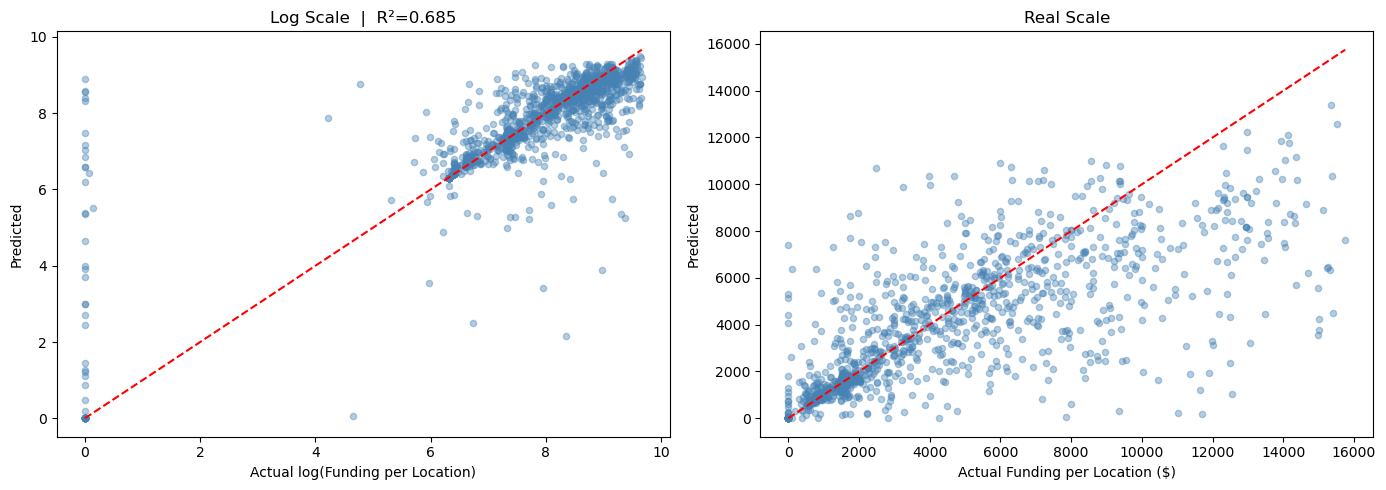

In [37]:
# --- Predicted vs Actual ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, s=20, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Actual log(Funding per Location)')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Log Scale  |  R²={r2:.3f}')

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)
axes[1].scatter(y_test_real, y_pred_real, alpha=0.4, s=20, color='steelblue')
lims2 = [min(y_test_real.min(), y_pred_real.min()), max(y_test_real.max(), y_pred_real.max())]
axes[1].plot(lims2, lims2, 'r--')
axes[1].set_xlabel('Actual Funding per Location ($)')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Real Scale')

plt.tight_layout()
plt.savefig('rf_v2_predictions.png', dpi=150)
plt.show()

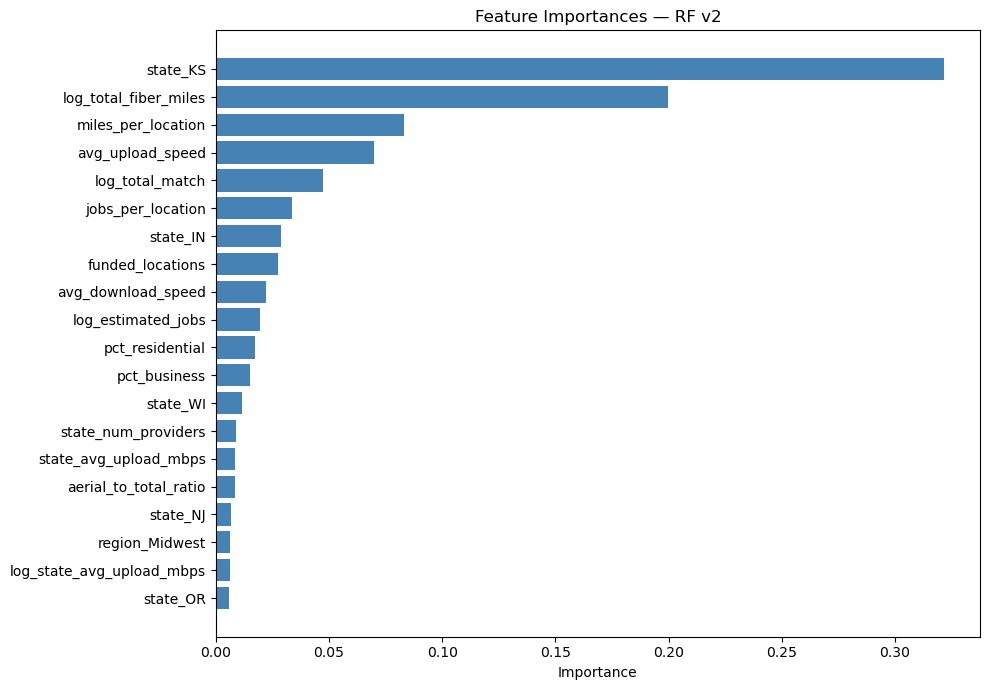

                         feature   importance
                        state_KS 3.214755e-01
           log_total_fiber_miles 1.999294e-01
              miles_per_location 8.301799e-02
                avg_upload_speed 6.983480e-02
                 log_total_match 4.717555e-02
               jobs_per_location 3.379261e-02
                        state_IN 2.886340e-02
                funded_locations 2.749848e-02
              avg_download_speed 2.230257e-02
              log_estimated_jobs 1.944035e-02
                 pct_residential 1.746547e-02
                    pct_business 1.490341e-02
                        state_WI 1.160897e-02
             state_num_providers 8.932224e-03
           state_avg_upload_mbps 8.566614e-03
           aerial_to_total_ratio 8.414722e-03
                        state_NJ 6.608134e-03
                  region_Midwest 6.108766e-03
       log_state_avg_upload_mbps 6.038815e-03
                        state_OR 5.717975e-03
log_estimated_miles_buried_fiber 5

In [38]:
# --- Feature Importance ---
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

top20 = importance_df.head(20)
plt.figure(figsize=(10, 7))
plt.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importances — RF v2')
plt.tight_layout()
plt.savefig('rf_v2_feature_importance.png', dpi=150)
plt.show()

print(importance_df.to_string(index=False))

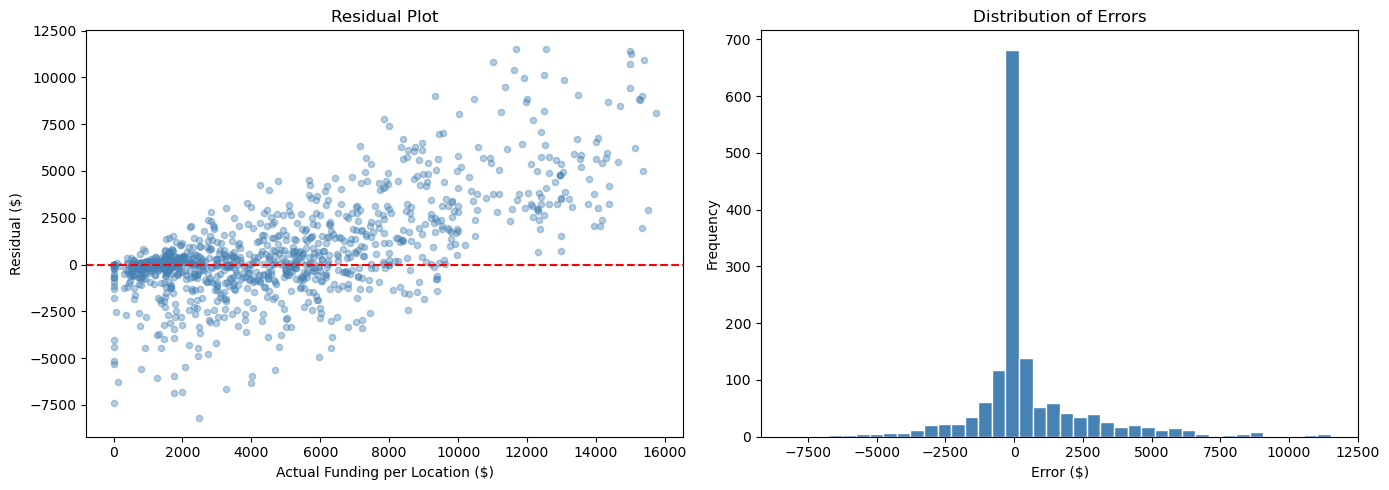

In [39]:
# --- Residuals ---
residuals = np.expm1(y_test) - np.expm1(y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(np.expm1(y_test), residuals, alpha=0.4, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Actual Funding per Location ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].set_title('Residual Plot')

axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Error ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Errors')

plt.tight_layout()
plt.savefig('rf_v2_residuals.png', dpi=150)
plt.show()

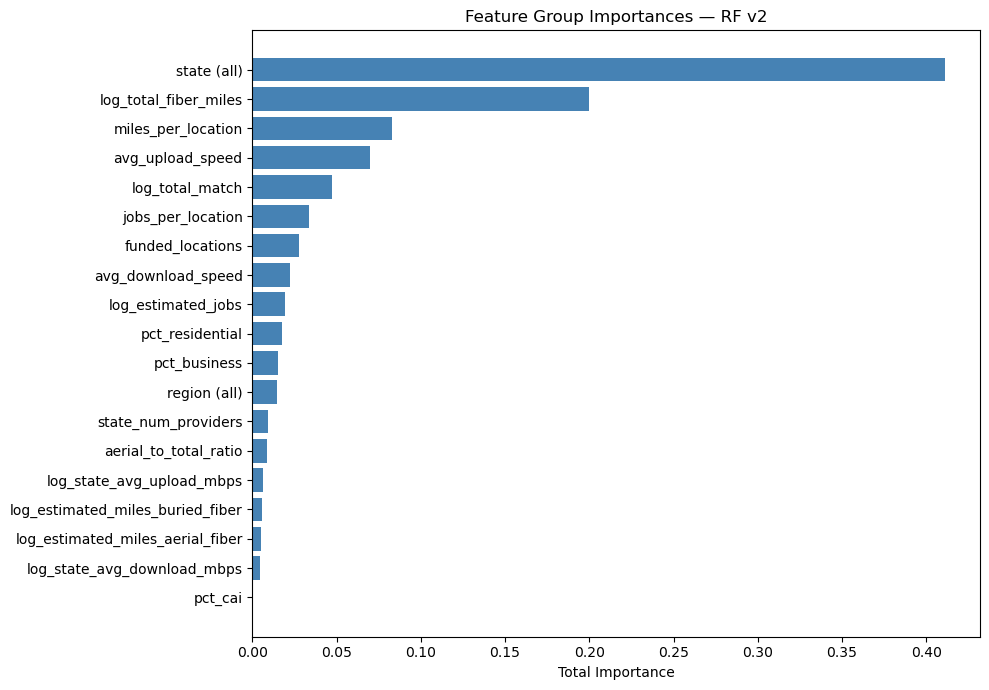

group
state (all)                         0.411385
log_total_fiber_miles               0.199929
miles_per_location                  0.083018
avg_upload_speed                    0.069835
log_total_match                     0.047176
jobs_per_location                   0.033793
funded_locations                    0.027498
avg_download_speed                  0.022303
log_estimated_jobs                  0.019440
pct_residential                     0.017465
pct_business                        0.014903
region (all)                        0.014586
state_num_providers                 0.008932
aerial_to_total_ratio               0.008415
log_state_avg_upload_mbps           0.006039
log_estimated_miles_buried_fiber    0.005648
log_estimated_miles_aerial_fiber    0.005198
log_state_avg_download_mbps         0.004304
pct_cai                             0.000133


In [40]:
# Group state dummies and region dummies into single aggregate scores
importance_df['group'] = importance_df['feature'].apply(
    lambda x: 'state (all)' if x.startswith('state_') and x != 'state_num_providers'
            else ('region (all)' if x.startswith('region_') else x)
)
grouped = importance_df.groupby('group')['importance'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(grouped.index[::-1], grouped.values[::-1], color='steelblue')
plt.xlabel('Total Importance')
plt.title('Feature Group Importances — RF v2')
plt.tight_layout()
plt.show()

print(grouped.to_string())